Sales Analysis
About the Dataset
The dataset consists of 11 columns, each column representing an attribute of purchase on a product - Order ID - A unique ID for each order placed on a product Product - Item that is purchased Quantity Ordered - Describes how many of that products are ordered Price Each - Price of a unit of that product Order Date - Date on which the order is placed Purchase Address - Address to where the order is shipped Month, Sales, City, Hour - Extra attributes formed from the above.

Acknowledgements
Dataset is downloaded and compiled from KeithGalli's GitHub repository on Pandas Data Science Tasks.

The objective of this dataset is to derive the meaningful insights from this data and get further intutions



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Sales Data.csv")
df

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
...,...,...,...,...,...,...,...,...,...,...,...
185945,13617,222905,AAA Batteries (4-pack),1,2.99,2019-06-07 19:02:00,"795 Pine St, Boston, MA 02215",6,2.99,Boston,19
185946,13618,222906,27in FHD Monitor,1,149.99,2019-06-01 19:29:00,"495 North St, New York City, NY 10001",6,149.99,New York City,19
185947,13619,222907,USB-C Charging Cable,1,11.95,2019-06-22 18:57:00,"319 Ridge St, San Francisco, CA 94016",6,11.95,San Francisco,18
185948,13620,222908,USB-C Charging Cable,1,11.95,2019-06-26 18:35:00,"916 Main St, San Francisco, CA 94016",6,11.95,San Francisco,18


UNDERSTANDING THE DATASET

In [3]:
df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [4]:
df.shape

(185950, 11)

In [5]:
df.size

2045450

In [6]:
df.columns

Index(['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  object 
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  object 
 6   Purchase Address  185950 non-null  object 
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  object 
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 15.6+ MB


In [8]:
df.describe()

,Unnamed: 0,Order ID,Quantity Ordered,Price Each,Month,Sales,Hour
count,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000
mean,8340.388475,230417.569379,1.124383,184.399735,7.059140,185.490917,14.413305
std,5450.554093,51512.737110,0.442793,332.731330,3.502996,332.919771,5.423416
min,0.000000,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,3894.000000,185831.250000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,7786.000000,230367.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,11872.000000,275035.750000,1.000000,150.000000,10.000000,150.000000,19.000000
max,25116.000000,319670.000000,9.000000,1700.000000,12.000000,3400.000000,23.000000


# Data Quality Assessment

Before performing data visualization and analysis, it is essential to evaluate the quality of the dataset. In this section, we will identify missing values, duplicate records, and other potential issues that may affect the accuracy and reliability of our analysis.

In [9]:
df.isnull().sum()

Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

Inference

No missing records were found in any of the column of the given data set meaning the dataset is already somewhat cleansed

## Checking for Duplicate Records

Duplicate records may occur due to data collection errors, repeated sensor readings, or accidental duplication during data storage. Identifying duplicate records is an essential data preprocessing step because they can bias statistical analysis and produce misleading insights. Therefore, we verify whether the dataset contains any duplicate observations before proceeding with further analysis.

In [10]:
df.duplicated().sum()

np.int64(0)

### Inference

The duplicate record check returned **0**, indicating that there are no duplicate observations in the dataset. Since each row represents a unique data point, no duplicate removal is required before proceeding with further analysis.

In [11]:
df.nunique()

Unnamed: 0           25093
Order ID            178437
Product                 19
Quantity Ordered         9
Price Each              17
Order Date          142395
Purchase Address    140787
Month                   12
Sales                   53
City                     9
Hour                    24
dtype: int64

In [12]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [13]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
...,...,...,...,...,...,...,...,...,...,...
185945,222905,AAA Batteries (4-pack),1,2.99,2019-06-07 19:02:00,"795 Pine St, Boston, MA 02215",6,2.99,Boston,19
185946,222906,27in FHD Monitor,1,149.99,2019-06-01 19:29:00,"495 North St, New York City, NY 10001",6,149.99,New York City,19
185947,222907,USB-C Charging Cable,1,11.95,2019-06-22 18:57:00,"319 Ridge St, San Francisco, CA 94016",6,11.95,San Francisco,18
185948,222908,USB-C Charging Cable,1,11.95,2019-06-26 18:35:00,"916 Main St, San Francisco, CA 94016",6,11.95,San Francisco,18


## Business Question 1: Which month had the highest sales?

Understanding monthly sales trends helps businesses identify peak sales periods. This information can be used for inventory planning, staffing, marketing campaigns, and forecasting future demand.

In [14]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64

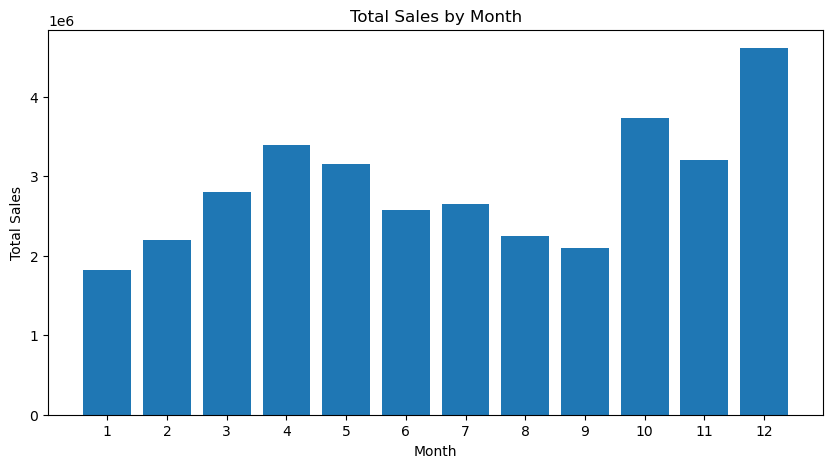

In [15]:
plt.figure(figsize=(10,5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))

plt.show()

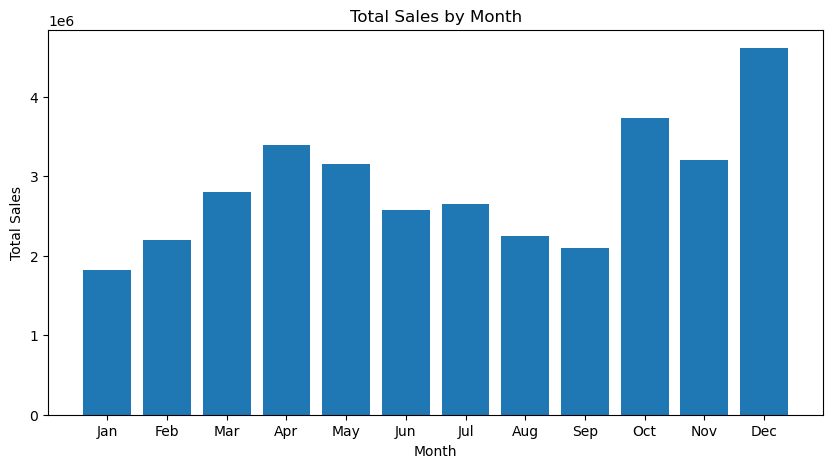

In [16]:
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10,5))
plt.bar(month_names, monthly_sales.values)

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

## Business Question 2: Which city generated the highest sales?

Analyzing city-wise sales helps the company identify its strongest markets. This information can be used to focus marketing efforts, improve inventory distribution, and plan business expansion in high-performing cities.


In [17]:
city_sales = df.groupby("City")["Sales"].sum()

city_sales

City
Atlanta          2795498.58
Austin           1819581.75
Boston           3661642.01
Dallas           2767975.40
Los Angeles      5452570.80
New York City    4664317.43
Portland         2320490.61
San Francisco    8262203.91
Seattle          2747755.48
Name: Sales, dtype: float64

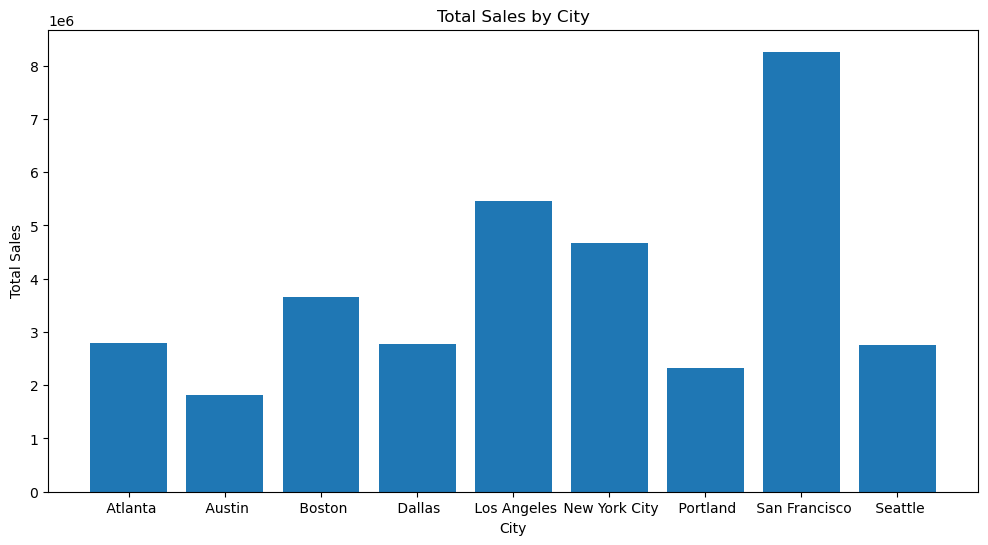

In [18]:
plt.figure(figsize=(12,6))
plt.bar(city_sales.index, city_sales.values)

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

## Business Question 3: At what hour are the maximum number of orders placed?

Identifying peak ordering hours helps businesses optimize staffing, customer support, delivery operations, and promotional campaigns.

In [21]:
order_count=df.groupby("Hour")["Order ID"].count()
order_count

Hour
0      3910
1      2350
2      1243
3       831
4       854
5      1321
6      2482
7      4011
8      6256
9      8748
10    10944
11    12411
12    12587
13    12129
14    10984
15    10175
16    10384
17    10899
18    12280
19    12905
20    12228
21    10921
22     8822
23     6275
Name: Order ID, dtype: int64

Text(0, 0.5, 'Number of Order')

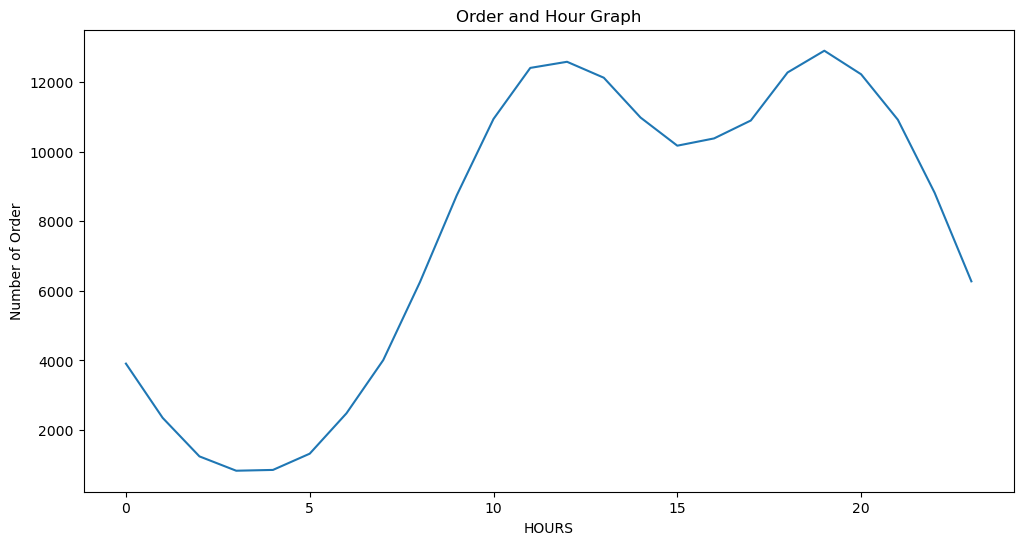

In [26]:
plt.figure(figsize=(12,6))
plt.plot(order_count.index,order_count.values)

plt.title("Order and Hour Graph")
plt.xlabel("HOURS")
plt.ylabel("Number of Order")



## Business Question 4: Which product sold the most?

Analyzing product-wise sales helps identify the best-selling products. This enables businesses to manage inventory effectively, understand customer demand, and make informed marketing and production decisions.

In [27]:
sold_products=df.groupby("Product")["Quantity Ordered"].sum()
sold_products

Product
20in Monitor                   4129
27in 4K Gaming Monitor         6244
27in FHD Monitor               7550
34in Ultrawide Monitor         6199
AA Batteries (4-pack)         27635
AAA Batteries (4-pack)        31017
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
Flatscreen TV                  4819
Google Phone                   5532
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23217
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
USB-C Charging Cable          23975
Vareebadd Phone                2068
Wired Headphones              20557
iPhone                         6849
Name: Quantity Ordered, dtype: int64

Text(0.5, 0, 'Quantity of each product')

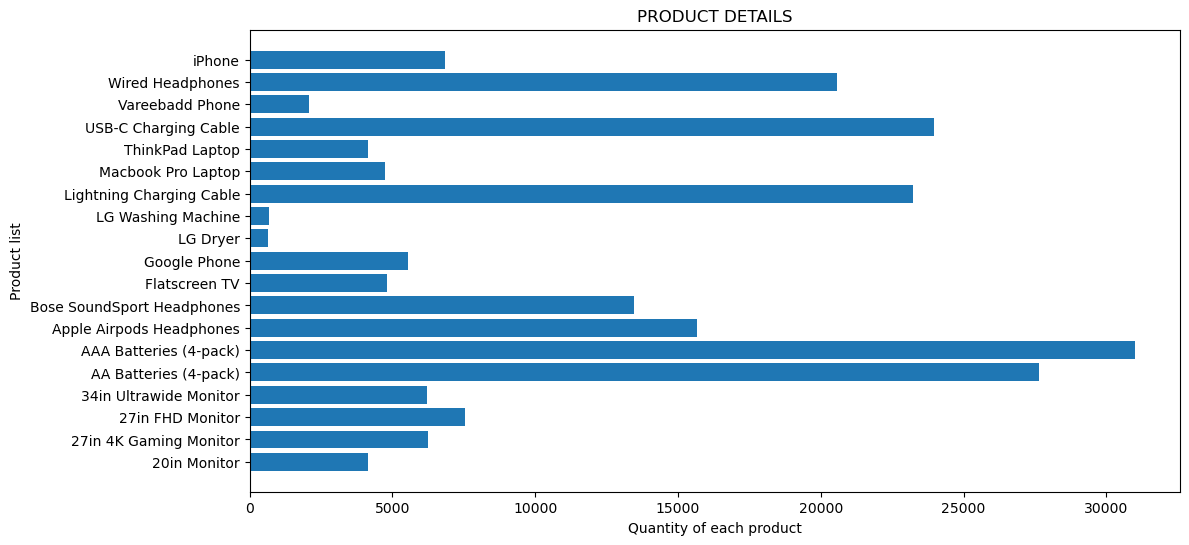

In [31]:
plt.figure(figsize=(12,6))
plt.barh(sold_products.index,sold_products.values)

plt.title("PRODUCT DETAILS")
plt.ylabel("Product list")
plt.xlabel("Quantity of each product")
#plt.xlabel("")

## Business Question 5: Which product generated the highest revenue?

Analyzing product-wise revenue helps identify the products that contribute the most to the company's income. This enables better pricing, marketing, and inventory decisions.

In [32]:
revenue_generated=df.groupby("Product")["Sales"].sum()
revenue_generated

Product
20in Monitor                   454148.71
27in 4K Gaming Monitor        2435097.56
27in FHD Monitor              1132424.50
34in Ultrawide Monitor        2355558.01
AA Batteries (4-pack)          106118.40
AAA Batteries (4-pack)          92740.83
Apple Airpods Headphones      2349150.00
Bose SoundSport Headphones    1345565.43
Flatscreen TV                 1445700.00
Google Phone                  3319200.00
LG Dryer                       387600.00
LG Washing Machine             399600.00
Lightning Charging Cable       347094.15
Macbook Pro Laptop            8037600.00
ThinkPad Laptop               4129958.70
USB-C Charging Cable           286501.25
Vareebadd Phone                827200.00
Wired Headphones               246478.43
iPhone                        4794300.00
Name: Sales, dtype: float64

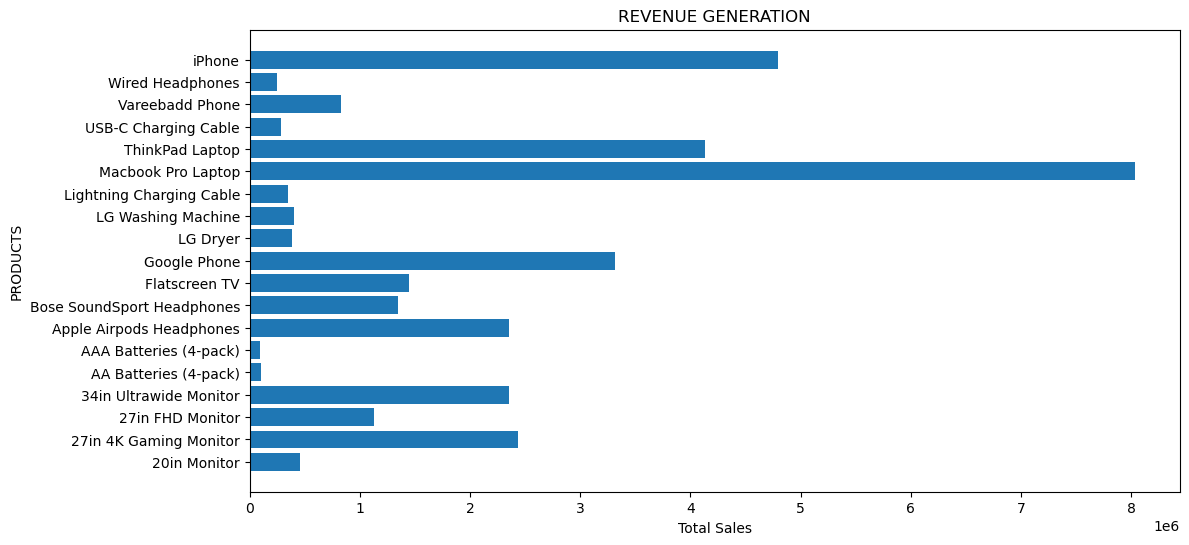

In [33]:
plt.figure(figsize=(12,6))
plt.barh(revenue_generated.index,revenue_generated.values)

plt.title("REVENUE GENERATION")
plt.ylabel("PRODUCTS")
plt.xlabel("Total Sales")

plt.show()

## Business Question 6: What is the average sales value per order?

Calculating the average sales value per order helps businesses understand the typical revenue generated from a customer's purchase. This metric can be used to evaluate customer spending behavior and identify opportunities to increase the average order value through cross-selling and promotional strategies.

In [34]:
average_sales = df["Sales"].mean()

print("Average Sales per Order:", average_sales)

Average Sales per Order: 185.490916751815


# Conclusion

This project involved analyzing a sales dataset to identify key business insights using Python, Pandas, Matplotlib, and Seaborn.

The analysis revealed monthly sales trends, city-wise revenue, peak ordering hours, best-selling products, highest revenue-generating products, and the average sales value per order.

These insights can help businesses make data-driven decisions related to inventory management, marketing strategies, staffing, and product planning. Overall, this project demonstrates how data analysis can transform raw sales data into meaningful business insights that support better decision-making.